# Day 2 — Baseline Recommenders và GRU4Rec

**Mục tiêu cuối ngày**

1. Kiểm tra dữ liệu Ngày 1.
2. Chuẩn bị file RecBole có thứ tự tương tác ổn định.
3. Chạy ba mô hình:
   - Most Popular
   - ItemKNN
   - GRU4Rec
4. Đánh giá bằng Recall@10, NDCG@10, MRR@10, Hit@10 và Candidate Recall@100.
5. Xuất Top-100 candidates của GRU4Rec để dùng trong Ngày 3–4.
6. Lưu kết quả, cấu hình và checkpoint lên Google Drive.

> Chạy từng ô từ trên xuống dưới. Không bấm **Run all** ngay lần đầu.

## Bước 1 — Bật GPU T4

Trên thanh menu Colab:

**Thời gian chạy → Thay đổi loại thời gian chạy → T4 GPU → Lưu**

Sau đó chạy ô dưới đây.

In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ Chưa có GPU. Pop và ItemKNN vẫn chạy được, nhưng GRU4Rec sẽ chậm hơn.")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## Bước 2 — Cài RecBole và thư viện tương thích

RecBole 1.2.1 được khóa phiên bản để kết quả có thể tái lập.

Sau khi ô này chạy xong, hãy chọn:

**Thời gian chạy → Khởi động lại phiên**

Sau khi khởi động lại, **không chạy lại ô cài đặt**; tiếp tục từ Bước 3.

In [2]:
!pip -q install --no-deps "recbole==1.2.1"
!pip -q install         "numpy==1.26.4"         "scipy==1.11.4"         "pandas==2.2.2"         "scikit-learn>=1.4,<1.6"         "PyYAML>=6.0"         "colorlog>=6.8"         "colorama>=0.4.6"         "tensorboard>=2.15"         "thop>=0.1.1"         "tabulate>=0.9"         "tqdm>=4.66"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 87.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 125.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
recbole 1.2.1 requires ray<=2.6.3,>=1.13.0, which is not installed.
recbole 1.2.1 requires texttable>=0.9.0, which is not installed.
recbole 1.2.1 requires colorama==0.4.4, but you have colorama 0.4.6 which is incompatible.
recbole 1.2.1 requires colorlog==4.7.2, but you have colorlog 6.10.1 which is incompatible.
inequality 1.1.2 requires scipy>=

In [3]:
!pip -q install \
    "colorama==0.4.4" \
    "colorlog==4.7.2" \
    "texttable==1.7.0" \
    "psutil>=5.9.0" \
    "plotly>=5.0.0"


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
recbole 1.2.1 requires ray<=2.6.3,>=1.13.0, which is not installed.


## Bước 3 — Kết nối Google Drive

Chạy bước này sau khi đã khởi động lại phiên.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## Bước 4 — Tạo đường dẫn Ngày 2

In [2]:
from pathlib import Path

ROOT = Path("/content/drive/MyDrive/llm-next-item-recommendation")

PROCESSED_DIR = ROOT / "data" / "processed"
RECBOLE_ROOT = ROOT / "data" / "recbole"
DAY2_DATASET_NAME = "all_beauty_day2"
DAY2_DATASET_DIR = RECBOLE_ROOT / DAY2_DATASET_NAME

MODEL_DIR = ROOT / "models" / "recbole"
OUTPUT_DIR = ROOT / "outputs" / "day2"
CONFIG_DIR = ROOT / "configs"

for folder in [
    DAY2_DATASET_DIR,
    MODEL_DIR,
    OUTPUT_DIR,
    CONFIG_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Root:", ROOT)
print("Day 2 dataset folder:", DAY2_DATASET_DIR)
print("Model folder:", MODEL_DIR)
print("Output folder:", OUTPUT_DIR)

Root: /content/drive/MyDrive/llm-next-item-recommendation
Day 2 dataset folder: /content/drive/MyDrive/llm-next-item-recommendation/data/recbole/all_beauty_day2
Model folder: /content/drive/MyDrive/llm-next-item-recommendation/models/recbole
Output folder: /content/drive/MyDrive/llm-next-item-recommendation/outputs/day2


## Bước 5 — Kiểm tra file Ngày 1

Nếu có dấu ❌, dừng lại và chạy lại Bước 12–18 của notebook Ngày 1.

In [3]:
required_day1_files = [
    PROCESSED_DIR / "interactions_full.parquet",
    PROCESSED_DIR / "train.parquet",
    PROCESSED_DIR / "valid.parquet",
    PROCESSED_DIR / "test.parquet",
    PROCESSED_DIR / "items.parquet",
]

missing_day1_files = []

for file_path in required_day1_files:
    if file_path.exists():
        size_mb = file_path.stat().st_size / (1024 * 1024)
        print(f"✅ {file_path.name} — {size_mb:.2f} MB")
    else:
        print(f"❌ {file_path}")
        missing_day1_files.append(str(file_path))

if missing_day1_files:
    raise FileNotFoundError(
        "Thiếu file Ngày 1. Hãy hoàn thành notebook Ngày 1 trước."
    )

print("\n✅ Đã tìm thấy toàn bộ file cần thiết.")

✅ interactions_full.parquet — 0.23 MB
✅ train.parquet — 0.18 MB
✅ valid.parquet — 0.07 MB
✅ test.parquet — 0.07 MB
✅ items.parquet — 0.83 MB

✅ Đã tìm thấy toàn bộ file cần thiết.


## Bước 6 — Import thư viện và kiểm tra môi trường

Ô này cũng thêm bản vá tương thích với thay đổi `torch.load` ở các phiên bản PyTorch mới.

In [4]:
import gc
import json
import logging
import platform
import sys
import time
import warnings
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
import torch

import recbole

warnings.filterwarnings("ignore")

# PyTorch mới có thể dùng weights_only=True mặc định.
# Checkpoint RecBole chứa cả config, nên cần weights_only=False.
_original_torch_load = torch.load

def torch_load_compatible(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _original_torch_load(*args, **kwargs)

torch.load = torch_load_compatible

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("Python:", sys.version)
print("Platform:", platform.platform())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("SciPy:", scipy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__)
print("RecBole:", recbole.__version__)
print("CUDA:", torch.cuda.is_available())

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
NumPy: 1.26.4
Pandas: 2.2.2
SciPy: 1.11.4
Scikit-learn: 1.5.2
PyTorch: 2.11.0+cu128
RecBole: 1.2.1
CUDA: True


## Bước 7 — Đọc dữ liệu Ngày 1

Người dùng phải có ít nhất bốn tương tác để sau khi dành:

- một tương tác cho validation;
- một tương tác cho test;

GRU4Rec vẫn còn ít nhất một cặp sequence–target để học.

In [5]:
interactions = pd.read_parquet(
    PROCESSED_DIR / "interactions_full.parquet"
)
valid_day1 = pd.read_parquet(
    PROCESSED_DIR / "valid.parquet"
)
test_day1 = pd.read_parquet(
    PROCESSED_DIR / "test.parquet"
)
items = pd.read_parquet(
    PROCESSED_DIR / "items.parquet"
)

interactions["user_id"] = interactions["user_id"].astype(str)
interactions["item_id"] = interactions["item_id"].astype(str)

valid_day1["user_id"] = valid_day1["user_id"].astype(str)
valid_day1["item_id"] = valid_day1["item_id"].astype(str)

test_day1["user_id"] = test_day1["user_id"].astype(str)
test_day1["item_id"] = test_day1["item_id"].astype(str)

user_counts = interactions.groupby("user_id").size()

MIN_USER_INTERACTIONS = 4
eligible_users = user_counts[
    user_counts >= MIN_USER_INTERACTIONS
].index

model_interactions = interactions[
    interactions["user_id"].isin(eligible_users)
].copy()

valid_day1 = valid_day1[
    valid_day1["user_id"].isin(eligible_users)
].copy()

test_day1 = test_day1[
    test_day1["user_id"].isin(eligible_users)
].copy()

print("Original interactions:", f"{len(interactions):,}")
print("Original users:", f"{interactions['user_id'].nunique():,}")
print("Modeling interactions:", f"{len(model_interactions):,}")
print("Modeling users:", f"{model_interactions['user_id'].nunique():,}")
print("Modeling items:", f"{model_interactions['item_id'].nunique():,}")
print(
    "Minimum interactions per modeling user:",
    model_interactions.groupby("user_id").size().min(),
)

if model_interactions["user_id"].nunique() < 100:
    print(
        "⚠️ Dataset có dưới 100 users. Pipeline vẫn chạy được, "
        "nhưng kết quả chỉ nên xem là proof of concept."
    )

Original interactions: 9,079
Original users: 1,266
Modeling interactions: 7,813
Modeling users: 844
Modeling items: 1,446
Minimum interactions per modeling user: 4


## Bước 8 — Tạo file RecBole có thứ tự ổn định

Timestamp gốc đôi khi có thể trùng nhau. Vì vậy ta:

1. Sắp xếp theo user, timestamp và item ID.
2. Tạo `sequence_timestamp` tăng dần trong từng user.

Giá trị này chỉ biểu diễn **thứ tự**, không thay đổi chuỗi hành vi.

In [6]:
model_interactions = model_interactions.sort_values(
    ["user_id", "timestamp", "item_id"]
).reset_index(drop=True)

model_interactions["sequence_timestamp"] = (
    model_interactions.groupby("user_id").cumcount() + 1
).astype(float)

recbole_interactions = model_interactions[
    ["user_id", "item_id", "sequence_timestamp"]
].copy()

recbole_interactions.columns = [
    "user_id:token",
    "item_id:token",
    "timestamp:float",
]

recbole_file = (
    DAY2_DATASET_DIR / f"{DAY2_DATASET_NAME}.inter"
)

recbole_interactions.to_csv(
    recbole_file,
    sep="\t",
    index=False,
)

print("Saved:", recbole_file)
print("Rows:", f"{len(recbole_interactions):,}")
display(recbole_interactions.head())

Saved: /content/drive/MyDrive/llm-next-item-recommendation/data/recbole/all_beauty_day2/all_beauty_day2.inter
Rows: 7,813


,user_id:token,item_id:token,timestamp:float
0,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,B089R7S73D,1.0
1,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,B081D2R47W,2.0
2,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,B087ZQK2G8,3.0
3,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,B08BF4BKKM,4.0
4,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,B0841WQNNZ,5.0


## Bước 9 — Kiểm tra split có khớp Ngày 1 hay không

Với mỗi user:

- dòng cuối phải là test target;
- dòng áp chót phải là validation target.

In [7]:
ordered = model_interactions.sort_values(
    ["user_id", "sequence_timestamp"]
)

derived_test = (
    ordered.groupby("user_id")
    .tail(1)[["user_id", "item_id"]]
    .rename(columns={"item_id": "derived_test_item"})
)

derived_valid = (
    ordered.groupby("user_id")
    .nth(-2)
    .reset_index()[["user_id", "item_id"]]
    .rename(columns={"item_id": "derived_valid_item"})
)

test_check = test_day1[
    ["user_id", "item_id"]
].rename(columns={"item_id": "day1_test_item"})

valid_check = valid_day1[
    ["user_id", "item_id"]
].rename(columns={"item_id": "day1_valid_item"})

test_compare = derived_test.merge(
    test_check,
    on="user_id",
    how="left",
)

valid_compare = derived_valid.merge(
    valid_check,
    on="user_id",
    how="left",
)

test_match_rate = (
    test_compare["derived_test_item"]
    == test_compare["day1_test_item"]
).mean()

valid_match_rate = (
    valid_compare["derived_valid_item"]
    == valid_compare["day1_valid_item"]
).mean()

print(f"Test target match rate: {test_match_rate:.2%}")
print(f"Validation target match rate: {valid_match_rate:.2%}")

if test_match_rate < 1 or valid_match_rate < 1:
    print(
        "⚠️ Có một số timestamp trùng nhau khiến thứ tự khác. "
        "Ngày 2 sẽ sử dụng thứ tự xác định trong file mới."
    )
else:
    print("✅ Thứ tự Ngày 2 khớp hoàn toàn với split Ngày 1.")

Test target match rate: 100.00%
Validation target match rate: 100.00%
✅ Thứ tự Ngày 2 khớp hoàn toàn với split Ngày 1.


## Bước 10 — Cấu hình đánh giá chung

RecBole sẽ dùng:

- `LS: valid_and_test`: leave-one-out cho validation và test;
- `TO`: sắp xếp theo thời gian;
- `full`: xếp hạng trên toàn bộ catalog;
- `NDCG@10`: chỉ số chọn epoch tốt nhất.

`Candidate Recall@100` chính là Recall@100 khi mỗi user có một test target.

In [8]:
item_count = model_interactions["item_id"].nunique()
CANDIDATE_K = min(100, max(1, item_count - 1))
TOPK_VALUES = sorted(set([10, CANDIDATE_K]))

BASE_CONFIG = {
    "data_path": str(RECBOLE_ROOT),
    "USER_ID_FIELD": "user_id",
    "ITEM_ID_FIELD": "item_id",
    "TIME_FIELD": "timestamp",
    "load_col": {
        "inter": ["user_id", "item_id", "timestamp"]
    },
    "ITEM_LIST_LENGTH_FIELD": "item_length",
    "LIST_SUFFIX": "_list",
    "MAX_ITEM_LIST_LENGTH": 20,
    "rm_dup_inter": None,
    "eval_args": {
        "split": {"LS": "valid_and_test"},
        "order": "TO",
        "group_by": "user",
        "mode": "full",
    },
    "metrics": [
        "Recall",
        "MRR",
        "NDCG",
        "Hit",
        "Precision",
    ],
    "topk": TOPK_VALUES,
    "valid_metric": "NDCG@10",
    "valid_metric_bigger": True,
    "eval_batch_size": 256,
    "train_batch_size": 256,
    "seed": RANDOM_SEED,
    "reproducibility": True,
    "show_progress": True,
    "use_gpu": bool(torch.cuda.is_available()),
    "gpu_id": 0,
    "checkpoint_dir": str(MODEL_DIR),
    "save_dataset": False,
    "save_dataloaders": False,
}

print("Candidate K:", CANDIDATE_K)
print("Metrics evaluated at:", TOPK_VALUES)
print("GPU used:", BASE_CONFIG["use_gpu"])

Candidate K: 100
Metrics evaluated at: [10, 100]
GPU used: True


## Bước 11 — Hàm chạy một mô hình RecBole

Bạn không cần sửa hàm này.

In [9]:
from recbole.config import Config
from recbole.data import create_dataset, data_preparation
from recbole.utils import (
    get_model,
    get_trainer,
    init_logger,
    init_seed,
)

def run_experiment(
    model_name: str,
    extra_config: dict | None = None,
    save_model: bool = False,
) -> dict:
    config_dict = deepcopy(BASE_CONFIG)

    if extra_config:
        config_dict.update(extra_config)

    # Tránh logger bị lặp khi chạy nhiều model trong một notebook.
    root_logger = logging.getLogger()
    for handler in root_logger.handlers[:]:
        root_logger.removeHandler(handler)

    config = Config(
        model=model_name,
        dataset=DAY2_DATASET_NAME,
        config_dict=config_dict,
    )

    init_seed(
        config["seed"],
        config["reproducibility"],
    )
    init_logger(config)

    dataset = create_dataset(config)
    train_data, valid_data, test_data = data_preparation(
        config,
        dataset,
    )

    init_seed(
        config["seed"] + config["local_rank"],
        config["reproducibility"],
    )

    model = get_model(config["model"])(
        config,
        train_data._dataset,
    ).to(config["device"])

    trainer = get_trainer(
        config["MODEL_TYPE"],
        config["model"],
    )(config, model)

    start_time = time.time()

    best_valid_score, best_valid_result = trainer.fit(
        train_data,
        valid_data,
        saved=save_model,
        show_progress=config["show_progress"],
    )

    test_result = trainer.evaluate(
        test_data,
        load_best_model=save_model,
        show_progress=config["show_progress"],
    )

    elapsed_seconds = time.time() - start_time

    return {
        "model_name": model_name,
        "config": config,
        "dataset": dataset,
        "model": model,
        "trainer": trainer,
        "train_data": train_data,
        "valid_data": valid_data,
        "test_data": test_data,
        "best_valid_score": float(best_valid_score),
        "best_valid_result": best_valid_result,
        "test_result": test_result,
        "elapsed_seconds": elapsed_seconds,
        "checkpoint": (
            str(trainer.saved_model_file)
            if save_model
            else None
        ),
    }

print("✅ Hàm run_experiment đã sẵn sàng.")

✅ Hàm run_experiment đã sẵn sàng.


## Bước 12 — Chạy Most Popular

Mô hình này luôn ưu tiên những sản phẩm xuất hiện nhiều trong train set.

Đây là baseline tối thiểu: mô hình phức tạp phải được so sánh với nó.

In [10]:
pop_bundle = run_experiment(
    model_name="Pop",
    extra_config={
        "epochs": 1,
    },
    save_model=False,
)

print("Pop test result:")
print(pop_bundle["test_result"])
print(
    "Runtime:",
    round(pop_bundle["elapsed_seconds"], 2),
    "seconds",
)

command line args [-f /root/.local/share/jupyter/runtime/kernel-de714af4-467d-40f8-8727-3fd5cb2b3481.json] will not be used in RecBole
28 Jun 09:44    INFO  [Training]: train_batch_size = [256] train_neg_sample_args: [{'distribution': 'uniform', 'sample_num': 1, 'alpha': 1.0, 'dynamic': False, 'candidate_num': 0}]
28 Jun 09:44    INFO  [Evaluation]: eval_batch_size = [256] eval_args: [{'split': {'LS': 'valid_and_test'}, 'order': 'TO', 'group_by': 'user', 'mode': {'valid': 'full', 'test': 'full'}}]
Train     0: 100%|████████████████████████| 48/48 [00:00<00:00, 103.00it/s, GPU RAM: 0.00 G/14.56 G]
28 Jun 09:44    INFO  epoch 0 training [time: 0.48s, train loss: 0.0000]
Evaluate   : 100%|██████████████████████| 844/844 [00:05<00:00, 159.93it/s, GPU RAM: 0.00 G/14.56 G]
28 Jun 09:44    INFO  epoch 0 evaluating [time: 5.31s, valid_score: 0.006200]
28 Jun 09:44    INFO  valid result: 
recall@10 : 0.0154    recall@100 : 0.0818    mrr@10 : 0.0034    mrr@100 : 0.0053    ndcg@10 : 0.0062    ndc

Pop test result:
OrderedDict({'recall@10': 0.0118, 'recall@100': 0.0581, 'mrr@10': 0.0029, 'mrr@100': 0.0042, 'ndcg@10': 0.005, 'ndcg@100': 0.0136, 'hit@10': 0.0118, 'hit@100': 0.0581, 'precision@10': 0.0012, 'precision@100': 0.0006})
Runtime: 10.43 seconds


## Bước 13 — Giải phóng bộ nhớ của Pop

Ta chỉ giữ metrics, không cần giữ model Pop trong RAM.

In [11]:
pop_result = {
    "model": "Most Popular",
    "valid": pop_bundle["best_valid_result"],
    "test": pop_bundle["test_result"],
    "runtime_seconds": pop_bundle["elapsed_seconds"],
}

del pop_bundle
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✅ Đã giải phóng bộ nhớ của Pop.")

✅ Đã giải phóng bộ nhớ của Pop.


## Bước 14 — Chạy ItemKNN

`k = 50` nghĩa là mỗi item được so với tối đa 50 item láng giềng gần nhất.

In [12]:
itemknn_bundle = run_experiment(
    model_name="ItemKNN",
    extra_config={
        "epochs": 1,
        "k": 50,
        "knn_method": "item",
        "shrink": 0.0,
    },
    save_model=False,
)

print("ItemKNN test result:")
print(itemknn_bundle["test_result"])
print(
    "Runtime:",
    round(itemknn_bundle["elapsed_seconds"], 2),
    "seconds",
)

command line args [-f /root/.local/share/jupyter/runtime/kernel-de714af4-467d-40f8-8727-3fd5cb2b3481.json] will not be used in RecBole
28 Jun 09:45    INFO  [Training]: train_batch_size = [256] train_neg_sample_args: [{'distribution': 'uniform', 'sample_num': 1, 'alpha': 1.0, 'dynamic': False, 'candidate_num': 0}]
28 Jun 09:45    INFO  [Evaluation]: eval_batch_size = [256] eval_args: [{'split': {'LS': 'valid_and_test'}, 'order': 'TO', 'group_by': 'user', 'mode': {'valid': 'full', 'test': 'full'}}]
Train     0: 100%|████████████████████████| 48/48 [00:00<00:00, 125.44it/s, GPU RAM: 0.00 G/14.56 G]
28 Jun 09:45    INFO  epoch 0 training [time: 0.39s, train loss: 0.0000]
Evaluate   : 100%|██████████████████████| 844/844 [00:06<00:00, 140.03it/s, GPU RAM: 0.00 G/14.56 G]
28 Jun 09:45    INFO  epoch 0 evaluating [time: 6.05s, valid_score: 0.025200]
28 Jun 09:45    INFO  valid result: 
recall@10 : 0.0474    recall@100 : 0.1682    mrr@10 : 0.0187    mrr@100 : 0.0221    ndcg@10 : 0.0252    ndc

ItemKNN test result:
OrderedDict({'recall@10': 0.0225, 'recall@100': 0.1434, 'mrr@10': 0.013, 'mrr@100': 0.0163, 'ndcg@10': 0.0152, 'ndcg@100': 0.0377, 'hit@10': 0.0225, 'hit@100': 0.1434, 'precision@10': 0.0023, 'precision@100': 0.0014})
Runtime: 12.08 seconds


## Bước 15 — Giải phóng bộ nhớ của ItemKNN

In [13]:
itemknn_result = {
    "model": "ItemKNN",
    "valid": itemknn_bundle["best_valid_result"],
    "test": itemknn_bundle["test_result"],
    "runtime_seconds": itemknn_bundle["elapsed_seconds"],
}

del itemknn_bundle
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("✅ Đã giải phóng bộ nhớ của ItemKNN.")

✅ Đã giải phóng bộ nhớ của ItemKNN.


## Bước 16 — Chạy GRU4Rec

Cấu hình nhẹ để phù hợp một người và thời gian năm ngày:

- embedding size: 64;
- hidden size: 64;
- một GRU layer;
- tối đa 50 epochs;
- early stopping sau 5 lần validation không cải thiện;
- cross-entropy loss.

Với dataset nhỏ, quá trình này thường không quá lâu trên T4.

In [14]:
gru4rec_bundle = run_experiment(
    model_name="GRU4Rec",
    extra_config={
        "epochs": 50,
        "stopping_step": 5,
        "learning_rate": 0.001,
        "embedding_size": 64,
        "hidden_size": 64,
        "num_layers": 1,
        "dropout_prob": 0.3,
        "loss_type": "CE",
        "train_neg_sample_args": None,
    },
    save_model=True,
)

print("GRU4Rec best validation result:")
print(gru4rec_bundle["best_valid_result"])

print("\nGRU4Rec test result:")
print(gru4rec_bundle["test_result"])

print("\nCheckpoint:")
print(gru4rec_bundle["checkpoint"])

print(
    "\nRuntime:",
    round(gru4rec_bundle["elapsed_seconds"], 2),
    "seconds",
)

command line args [-f /root/.local/share/jupyter/runtime/kernel-de714af4-467d-40f8-8727-3fd5cb2b3481.json] will not be used in RecBole
28 Jun 09:46    INFO  [Training]: train_batch_size = [256] train_neg_sample_args: [{'distribution': 'none', 'sample_num': 'none', 'alpha': 'none', 'dynamic': False, 'candidate_num': 0}]
28 Jun 09:46    INFO  [Evaluation]: eval_batch_size = [256] eval_args: [{'split': {'LS': 'valid_and_test'}, 'order': 'TO', 'group_by': 'user', 'mode': {'valid': 'full', 'test': 'full'}}]
Train     0: 100%|█████████████████████████| 21/21 [00:00<00:00, 22.03it/s, GPU RAM: 0.10 G/14.56 G]
28 Jun 09:46    INFO  epoch 0 training [time: 0.97s, train loss: 152.7434]
Evaluate   : 100%|██████████████████████████| 4/4 [00:00<00:00, 101.02it/s, GPU RAM: 0.10 G/14.56 G]
28 Jun 09:46    INFO  epoch 0 evaluating [time: 0.07s, valid_score: 0.003600]
28 Jun 09:46    INFO  valid result: 
recall@10 : 0.0095    recall@100 : 0.0972    mrr@10 : 0.0019    mrr@100 : 0.0037    ndcg@10 : 0.0036

GRU4Rec best validation result:
OrderedDict({'recall@10': 0.0545, 'recall@100': 0.2915, 'mrr@10': 0.0231, 'mrr@100': 0.0297, 'ndcg@10': 0.0304, 'ndcg@100': 0.0748, 'hit@10': 0.0545, 'hit@100': 0.2915, 'precision@10': 0.0055, 'precision@100': 0.0029})

GRU4Rec test result:
OrderedDict({'recall@10': 0.0486, 'recall@100': 0.2393, 'mrr@10': 0.0155, 'mrr@100': 0.0211, 'ndcg@10': 0.023, 'ndcg@100': 0.0593, 'hit@10': 0.0486, 'hit@100': 0.2393, 'precision@10': 0.0049, 'precision@100': 0.0024})

Checkpoint:
/content/drive/MyDrive/llm-next-item-recommendation/models/recbole/GRU4Rec-Jun-28-2026_09-46-10.pth

Runtime: 12.4 seconds


## Bước 17 — Tạo bảng so sánh ba mô hình

In [15]:
gru4rec_result = {
    "model": "GRU4Rec",
    "valid": gru4rec_bundle["best_valid_result"],
    "test": gru4rec_bundle["test_result"],
    "runtime_seconds": gru4rec_bundle["elapsed_seconds"],
}

experiment_results = [
    pop_result,
    itemknn_result,
    gru4rec_result,
]

metric_keys = [
    "recall@10",
    "mrr@10",
    "ndcg@10",
    "hit@10",
    "precision@10",
    f"recall@{CANDIDATE_K}",
]

comparison_rows = []

for experiment in experiment_results:
    row = {
        "model": experiment["model"],
        "runtime_seconds": round(
            experiment["runtime_seconds"],
            3,
        ),
    }

    for metric in metric_keys:
        row[f"valid_{metric}"] = experiment[
            "valid"
        ].get(metric, np.nan)

        row[f"test_{metric}"] = experiment[
            "test"
        ].get(metric, np.nan)

    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df)

comparison_df.to_csv(
    OUTPUT_DIR / "day2_model_comparison.csv",
    index=False,
)

print(
    "Saved:",
    OUTPUT_DIR / "day2_model_comparison.csv",
)

,model,runtime_seconds,valid_recall@10,test_recall@10,valid_mrr@10,test_mrr@10,valid_ndcg@10,test_ndcg@10,valid_hit@10,test_hit@10,valid_precision@10,test_precision@10,valid_recall@100,test_recall@100
0,Most Popular,10.428,0.0154,0.0118,0.0034,0.0029,0.0062,0.0050,0.0154,0.0118,0.0015,0.0012,0.0818,0.0581
1,ItemKNN,12.079,0.0474,0.0225,0.0187,0.0130,0.0252,0.0152,0.0474,0.0225,0.0047,0.0023,0.1682,0.1434
2,GRU4Rec,12.399,0.0545,0.0486,0.0231,0.0155,0.0304,0.0230,0.0545,0.0486,0.0055,0.0049,0.2915,0.2393


Saved: /content/drive/MyDrive/llm-next-item-recommendation/outputs/day2/day2_model_comparison.csv


## Bước 18 — Vẽ biểu đồ NDCG@10

Biểu đồ chỉ dùng để quan sát. Không kết luận mô hình tốt nhất chỉ dựa vào một chỉ số.

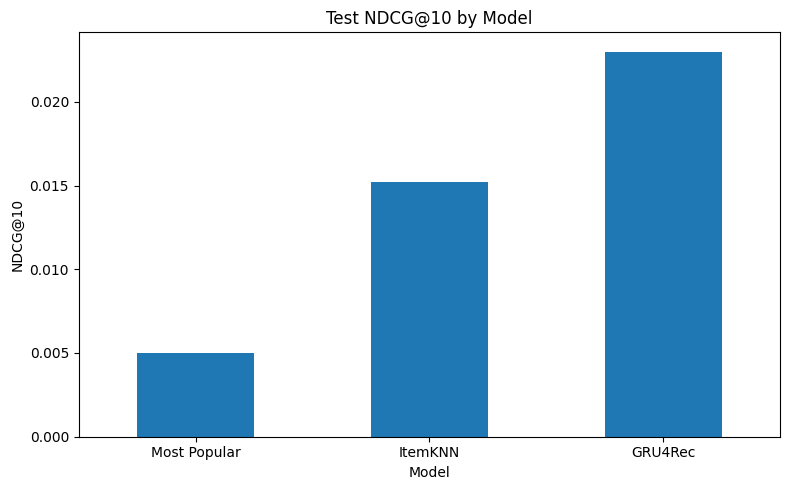

Saved: /content/drive/MyDrive/llm-next-item-recommendation/outputs/day2/day2_ndcg10_comparison.png


In [16]:
plot_df = comparison_df[
    ["model", "test_ndcg@10"]
].copy()

ax = plot_df.plot(
    x="model",
    y="test_ndcg@10",
    kind="bar",
    legend=False,
    figsize=(8, 5),
)

ax.set_title("Test NDCG@10 by Model")
ax.set_xlabel("Model")
ax.set_ylabel("NDCG@10")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

figure_path = OUTPUT_DIR / "day2_ndcg10_comparison.png"
plt.savefig(
    figure_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()

print("Saved:", figure_path)

## Bước 19 — Xuất Top-K candidates từ GRU4Rec

File test candidates sẽ được dùng ở Ngày 3–4 để:

- tạo product intentions;
- tính semantic similarity;
- rerank candidates bằng LLM intention.

RecBole tự loại padding và xử lý full-sort ranking.

In [18]:
from recbole.utils.case_study import full_sort_topk


def tensor_or_array_to_numpy(value):
    """Chuyển Tensor hoặc array về NumPy."""
    if torch.is_tensor(value):
        return value.detach().cpu().numpy()

    return np.asarray(value)


def export_gru4rec_candidates(
    data_loader,
    ground_truth_df: pd.DataFrame,
    split_name: str,
    k: int,
    user_batch_size: int = 128,
) -> pd.DataFrame:
    """
    Xuất Top-K candidates cho mỗi user.

    Phiên bản này tương thích với RecBole 1.2.1 và không sử dụng
    data_loader.uid_list.
    """

    dataset = data_loader.dataset
    model = gru4rec_bundle["model"]
    config = gru4rec_bundle["config"]

    model.eval()

    # Lấy danh sách user bên ngoài từ file ground truth
    external_users = (
        ground_truth_df["user_id"]
        .astype(str)
        .drop_duplicates()
        .to_numpy()
    )

    # Chuyển user token bên ngoài sang user ID nội bộ của RecBole
    internal_user_ids = dataset.token2id(
        dataset.uid_field,
        external_users,
    )

    internal_user_ids = np.asarray(
        internal_user_ids,
        dtype=np.int64,
    )

    print(
        f"{split_name}: {len(external_users)} users "
        f"— generating Top-{k} candidates"
    )

    # Tạo bảng user → sản phẩm thật
    truth_map = (
        ground_truth_df[
            ["user_id", "item_id"]
        ]
        .drop_duplicates(subset=["user_id"])
        .assign(
            user_id=lambda df: df["user_id"].astype(str),
            item_id=lambda df: df["item_id"].astype(str),
        )
        .set_index("user_id")["item_id"]
        .to_dict()
    )

    records = []

    # Chạy theo batch để tránh tràn RAM/GPU
    for start in range(
        0,
        len(internal_user_ids),
        user_batch_size,
    ):
        end = min(
            start + user_batch_size,
            len(internal_user_ids),
        )

        batch_internal_users = internal_user_ids[start:end]

        # RecBole trả về Top-K score và internal item IDs
        topk_scores, topk_internal_items = full_sort_topk(
            uid_series=batch_internal_users,
            model=model,
            test_data=data_loader,
            k=k,
            device=config["device"],
        )

        score_matrix = tensor_or_array_to_numpy(
            topk_scores
        )

        internal_item_matrix = tensor_or_array_to_numpy(
            topk_internal_items
        )

        # Chuyển internal user IDs về user tokens ban đầu
        batch_external_users = dataset.id2token(
            dataset.uid_field,
            batch_internal_users,
        )

        # Chuyển internal item IDs về item tokens ban đầu
        flat_internal_items = internal_item_matrix.reshape(-1)

        flat_external_items = dataset.id2token(
            dataset.iid_field,
            flat_internal_items,
        )

        external_item_matrix = np.asarray(
            flat_external_items
        ).reshape(internal_item_matrix.shape)

        for row_index, user_token in enumerate(
            batch_external_users
        ):
            user_token = str(user_token)
            true_item = truth_map.get(user_token)

            for rank_index in range(k):
                candidate_item = str(
                    external_item_matrix[
                        row_index,
                        rank_index,
                    ]
                )

                records.append(
                    {
                        "split": split_name,
                        "user_id": user_token,
                        "rank": rank_index + 1,
                        "item_id": candidate_item,
                        "gru4rec_score": float(
                            score_matrix[
                                row_index,
                                rank_index,
                            ]
                        ),
                        "ground_truth_item_id": true_item,
                        "is_ground_truth": (
                            candidate_item == true_item
                        ),
                    }
                )

        print(
            f"Processed {end}/{len(internal_user_ids)} users"
        )

    candidates = pd.DataFrame(records)

    # Kiểm tra thiếu ground truth
    missing_ground_truth = (
        candidates["ground_truth_item_id"]
        .isna()
        .sum()
    )

    if missing_ground_truth > 0:
        missing_users = (
            candidates.loc[
                candidates[
                    "ground_truth_item_id"
                ].isna(),
                "user_id",
            ]
            .nunique()
        )

        raise ValueError(
            f"{split_name}: thiếu ground truth cho "
            f"{missing_users} users."
        )

    return candidates


# Xuất candidates cho validation
valid_candidates = export_gru4rec_candidates(
    data_loader=gru4rec_bundle["valid_data"],
    ground_truth_df=valid_day1,
    split_name="validation",
    k=CANDIDATE_K,
)

# Xuất candidates cho test
test_candidates = export_gru4rec_candidates(
    data_loader=gru4rec_bundle["test_data"],
    ground_truth_df=test_day1,
    split_name="test",
    k=CANDIDATE_K,
)

print("\nValidation candidates shape:")
print(valid_candidates.shape)

print("\nTest candidates shape:")
print(test_candidates.shape)

display(test_candidates.head(10))

validation: 844 users — generating Top-100 candidates
Processed 128/844 users
Processed 256/844 users
Processed 384/844 users
Processed 512/844 users
Processed 640/844 users
Processed 768/844 users
Processed 844/844 users
test: 844 users — generating Top-100 candidates
Processed 128/844 users
Processed 256/844 users
Processed 384/844 users
Processed 512/844 users
Processed 640/844 users
Processed 768/844 users
Processed 844/844 users

Validation candidates shape:
(84400, 7)

Test candidates shape:
(84400, 7)


,split,user_id,rank,item_id,gru4rec_score,ground_truth_item_id,is_ground_truth
0,test,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,1,B0932Z1NM1,5.795252,B09XF4WD3V,False
1,test,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,2,B084WP4XS8,5.684075,B09XF4WD3V,False
2,test,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,3,B08MC3ZLV4,5.634042,B09XF4WD3V,False
3,test,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,4,B09473GGM4,5.624408,B09XF4WD3V,False
4,test,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,5,B085RS26YH,5.577702,B09XF4WD3V,False
5,test,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,6,B08R3F946X,5.477757,B09XF4WD3V,False
6,test,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,7,B0919R1CYT,5.438109,B09XF4WD3V,False
7,test,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,8,B0949MJRHK,5.359048,B09XF4WD3V,False
8,test,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,9,B097H7H3MT,5.346110,B09XF4WD3V,False
9,test,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,10,B0977LVHF8,5.341464,B09XF4WD3V,False


## Bước 20 — Kiểm tra Candidate Recall

Với một target cho mỗi user:

\[
CandidateRecall@K =
\frac{\text{số user có target trong Top-K}}
{\text{tổng số user}}
\]

Kết quả tính từ file candidates phải gần bằng Recall@K do RecBole báo cáo.

In [19]:
def candidate_recall(candidates: pd.DataFrame) -> float:
    return float(
        candidates.groupby("user_id")[
            "is_ground_truth"
        ].any().mean()
    )

valid_candidate_recall = candidate_recall(
    valid_candidates
)
test_candidate_recall = candidate_recall(
    test_candidates
)

recbole_valid_recall = gru4rec_bundle[
    "best_valid_result"
][f"recall@{CANDIDATE_K}"]

recbole_test_recall = gru4rec_bundle[
    "test_result"
][f"recall@{CANDIDATE_K}"]

print(
    f"Validation Candidate Recall@{CANDIDATE_K}:",
    round(valid_candidate_recall, 6),
)
print(
    f"RecBole validation Recall@{CANDIDATE_K}:",
    recbole_valid_recall,
)

print(
    f"\nTest Candidate Recall@{CANDIDATE_K}:",
    round(test_candidate_recall, 6),
)
print(
    f"RecBole test Recall@{CANDIDATE_K}:",
    recbole_test_recall,
)

print(
    "\nAbsolute test difference:",
    abs(
        test_candidate_recall
        - float(recbole_test_recall)
    ),
)

Validation Candidate Recall@100: 0.291469
RecBole validation Recall@100: 0.2915

Test Candidate Recall@100: 0.239336
RecBole test Recall@100: 0.2393

Absolute test difference: 3.649289099524888e-05


## Bước 21 — Lưu candidates và candidate pool

In [20]:
valid_candidates_path = (
    OUTPUT_DIR
    / f"gru4rec_top{CANDIDATE_K}_validation.parquet"
)

test_candidates_path = (
    OUTPUT_DIR
    / f"gru4rec_top{CANDIDATE_K}_test.parquet"
)

valid_candidates.to_parquet(
    valid_candidates_path,
    index=False,
)

test_candidates.to_parquet(
    test_candidates_path,
    index=False,
)

candidate_pool = pd.DataFrame(
    {
        "item_id": pd.concat(
            [
                valid_candidates["item_id"],
                test_candidates["item_id"],
            ]
        )
        .astype(str)
        .drop_duplicates()
        .sort_values()
        .values
    }
)

candidate_pool = candidate_pool.merge(
    items,
    on="item_id",
    how="left",
)

candidate_pool_path = (
    OUTPUT_DIR / "gru4rec_candidate_item_pool.parquet"
)

candidate_pool.to_parquet(
    candidate_pool_path,
    index=False,
)

print("Saved:", valid_candidates_path)
print("Saved:", test_candidates_path)
print("Saved:", candidate_pool_path)
print("Unique candidate items:", len(candidate_pool))

Saved: /content/drive/MyDrive/llm-next-item-recommendation/outputs/day2/gru4rec_top100_validation.parquet
Saved: /content/drive/MyDrive/llm-next-item-recommendation/outputs/day2/gru4rec_top100_test.parquet
Saved: /content/drive/MyDrive/llm-next-item-recommendation/outputs/day2/gru4rec_candidate_item_pool.parquet
Unique candidate items: 1048


## Bước 22 — Lưu cấu hình và tóm tắt Ngày 2

In [21]:
day2_summary = {
    "dataset_name": DAY2_DATASET_NAME,
    "interactions": int(len(model_interactions)),
    "users": int(
        model_interactions["user_id"].nunique()
    ),
    "items": int(
        model_interactions["item_id"].nunique()
    ),
    "minimum_user_interactions": int(
        model_interactions.groupby("user_id").size().min()
    ),
    "candidate_k": int(CANDIDATE_K),
    "gru4rec_checkpoint": gru4rec_bundle["checkpoint"],
    "validation_candidate_recall": (
        valid_candidate_recall
    ),
    "test_candidate_recall": test_candidate_recall,
    "random_seed": RANDOM_SEED,
    "device": str(
        gru4rec_bundle["config"]["device"]
    ),
}

with open(
    OUTPUT_DIR / "day2_summary.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        day2_summary,
        file,
        ensure_ascii=False,
        indent=2,
    )

gru4rec_config_export = {
    "epochs": 50,
    "stopping_step": 5,
    "learning_rate": 0.001,
    "embedding_size": 64,
    "hidden_size": 64,
    "num_layers": 1,
    "dropout_prob": 0.3,
    "loss_type": "CE",
    "max_item_list_length": 20,
    "train_batch_size": 256,
    "eval_batch_size": 256,
    "valid_metric": "NDCG@10",
    "topk": TOPK_VALUES,
    "split": "leave-one-out validation and test",
    "order": "temporal",
    "evaluation_mode": "full",
    "seed": RANDOM_SEED,
}

with open(
    CONFIG_DIR / "gru4rec_day2_config.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        gru4rec_config_export,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Saved Day 2 summary and GRU4Rec config.")

Saved Day 2 summary and GRU4Rec config.


## Bước 23 — Kiểm tra toàn bộ file Ngày 2

In [22]:
expected_day2_files = [
    OUTPUT_DIR / "day2_model_comparison.csv",
    OUTPUT_DIR / "day2_ndcg10_comparison.png",
    OUTPUT_DIR
    / f"gru4rec_top{CANDIDATE_K}_validation.parquet",
    OUTPUT_DIR
    / f"gru4rec_top{CANDIDATE_K}_test.parquet",
    OUTPUT_DIR / "gru4rec_candidate_item_pool.parquet",
    OUTPUT_DIR / "day2_summary.json",
    CONFIG_DIR / "gru4rec_day2_config.json",
]

print("KIỂM TRA FILE NGÀY 2\n")

missing_files = []

for file_path in expected_day2_files:
    if file_path.exists():
        size_mb = file_path.stat().st_size / (
            1024 * 1024
        )
        print(
            f"✅ {file_path.relative_to(ROOT)} "
            f"— {size_mb:.2f} MB"
        )
    else:
        print(
            f"❌ {file_path.relative_to(ROOT)}"
        )
        missing_files.append(str(file_path))

checkpoint_path = gru4rec_bundle["checkpoint"]

if checkpoint_path and Path(checkpoint_path).exists():
    size_mb = Path(checkpoint_path).stat().st_size / (
        1024 * 1024
    )
    print(
        f"✅ {Path(checkpoint_path).relative_to(ROOT)} "
        f"— {size_mb:.2f} MB"
    )
else:
    print("❌ Không tìm thấy GRU4Rec checkpoint")
    missing_files.append("GRU4Rec checkpoint")

print("\nKẾT QUẢ:")

if not missing_files:
    print("✅ ĐỦ FILE — HOÀN THÀNH NGÀY 2")
else:
    print(f"❌ Còn thiếu {len(missing_files)} file")
    for missing_file in missing_files:
        print("-", missing_file)

KIỂM TRA FILE NGÀY 2

✅ outputs/day2/day2_model_comparison.csv — 0.00 MB
✅ outputs/day2/day2_ndcg10_comparison.png — 0.03 MB
✅ outputs/day2/gru4rec_top100_validation.parquet — 0.80 MB
✅ outputs/day2/gru4rec_top100_test.parquet — 0.79 MB
✅ outputs/day2/gru4rec_candidate_item_pool.parquet — 0.56 MB
✅ outputs/day2/day2_summary.json — 0.00 MB
✅ configs/gru4rec_day2_config.json — 0.00 MB
✅ models/recbole/GRU4Rec-Jun-28-2026_09-46-10.pth — 1.40 MB

KẾT QUẢ:
✅ ĐỦ FILE — HOÀN THÀNH NGÀY 2


# Checklist hoàn thành Ngày 2

```text
[ ] Colab đang dùng T4 GPU
[ ] RecBole 1.2.1 import thành công
[ ] File all_beauty_day2.inter được tạo
[ ] Most Popular chạy thành công
[ ] ItemKNN chạy thành công
[ ] GRU4Rec chạy thành công
[ ] Có bảng day2_model_comparison.csv
[ ] Có GRU4Rec checkpoint
[ ] Có Top-K validation candidates
[ ] Có Top-K test candidates
[ ] Có candidate item pool
[ ] Candidate Recall được kiểm tra
[ ] Ô cuối hiện “HOÀN THÀNH NGÀY 2”
```

## File nên upload lên GitHub

- `02_baseline_recsys.ipynb`
- `requirements-day2.txt`
- `configs/gru4rec_day2_config.json`
- Có thể upload `outputs/day2/day2_model_comparison.csv`
- Có thể upload biểu đồ `.png`

## Không upload lên GitHub

- Raw/processed dataset
- Candidate Parquet files nếu quá lớn
- GRU4Rec checkpoint
- Thư mục `models/`

Các file lớn vẫn được giữ trong Google Drive để dùng ở Ngày 3–4.